# Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
df = pd.read_csv('../data/processed/modeling/inpatient_episodes.csv')

In [2]:
df.drop(columns = ['lookahead_months'], inplace=True)
df['episode_start'] = pd.to_datetime(df['episode_start'])
df['episode_end'] = pd.to_datetime(df['episode_end'])
df['admission_month'] = df['episode_start'].dt.month
df['admission_dow'] = df['episode_start'].dt.dayofweek
df['is_weekend'] = df['admission_dow'].isin([5, 6]).astype(int)
df['log_num_days'] = np.log1p(df['num_days'])
df.drop(columns=['episode_start', 'episode_end', 'num_days', 'admission_dow'], inplace=True)

In [3]:
def parse_age(age_str):
    if age_str == '90+':
        return 90 # mmmh?
    try:
        parts = age_str.split('-')
        return (int(parts[0]) + int(parts[1])) / 2
    except:
        return np.nan
df['age'] = df['age_group'].apply(parse_age)
df.drop(columns=['age_group'], inplace=True)

dept_counts = df['discharge_department'].value_counts()
rare_depts = dept_counts[dept_counts < 50].index
df['discharge_department_grouped'] = df['discharge_department'].apply(lambda x: 'Other' if x in rare_depts else x)

In [4]:
# ohe - one hot encoding
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
dept_encoded = ohe.fit_transform(df[['discharge_department_grouped']])
dept_columns = ohe.get_feature_names_out(['discharge_department_grouped'])
dept_df = pd.DataFrame(dept_encoded, columns=dept_columns, index=df.index)
# merge back to main df if needed
df = pd.concat([df, dept_df], axis=1)
# print(dept_df.head())

In [5]:
df['log_total_cost'] = np.log1p(df['total_cost'])
df.drop(columns=['total_cost'], inplace=True)
df.drop(columns=["episode_type"], inplace=True)

In [6]:
print("\nInfo:")
print(df.info())
# distribution of target variable
print("\nTarget variable distribution:")
print(df['is_readmitted'].value_counts(normalize=True))
print(df.head())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5590 entries, 0 to 5589
Data columns (total 54 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Unnamed: 0                                                     5590 non-null   int64  
 1   episode_id                                                     5590 non-null   int64  
 2   crypted_patient_id                                             5590 non-null   object 
 3   num_inpatient_events                                           5590 non-null   int64  
 4   lookback_months                                                5590 non-null   float64
 5   count_prior_inpatient                                          5590 non-null   int64  
 6   count_prior_emergency                                          5590 non-null   int64  
 7   count_prior_emergency_30days                         

In [7]:
# drop columns that are not useful 
df.drop(columns=['episode_id'], inplace=True)

# Feature Selection

C:\Users\kevin\AppData\Local\Temp\ipykernel_55416\106715679.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='num_comorbidities_binned', y='is_readmitted', data=df, order=order, errorbar=None, palette="Blues_d")


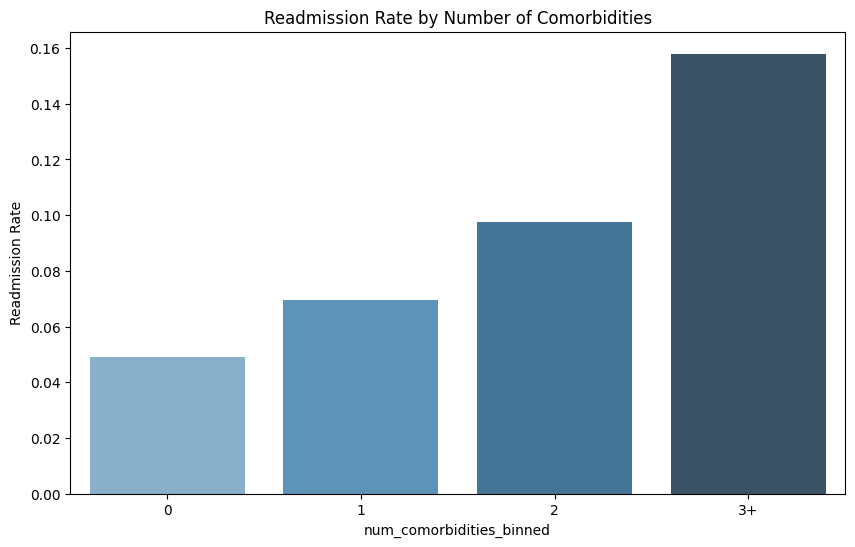

In [8]:
plt.figure(figsize=(10, 6))
# group num_comorbidities in 0, 1 and 3+ ordering the x-axis
df['num_comorbidities_binned'] = df['num_comorbidities'].apply(lambda x: '3+' if x >= 3 else (str(x)))
order = ['0', '1','2', '3+']
sns.barplot(x='num_comorbidities_binned', y='is_readmitted', data=df, order=order, errorbar=None, palette="Blues_d") 
plt.title("Readmission Rate by Number of Comorbidities")
plt.ylabel("Readmission Rate")
plt.show()
df.drop(columns=['num_comorbidities_binned'], inplace=True)

C:\Users\kevin\AppData\Local\Temp\ipykernel_55416\131600540.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_stats.index, y=dept_stats['mean'], ax=ax1, palette='Spectral', alpha=0.8)
C:\Users\kevin\AppData\Local\Temp\ipykernel_55416\131600540.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(dept_stats.index, rotation=90, fontsize=12)


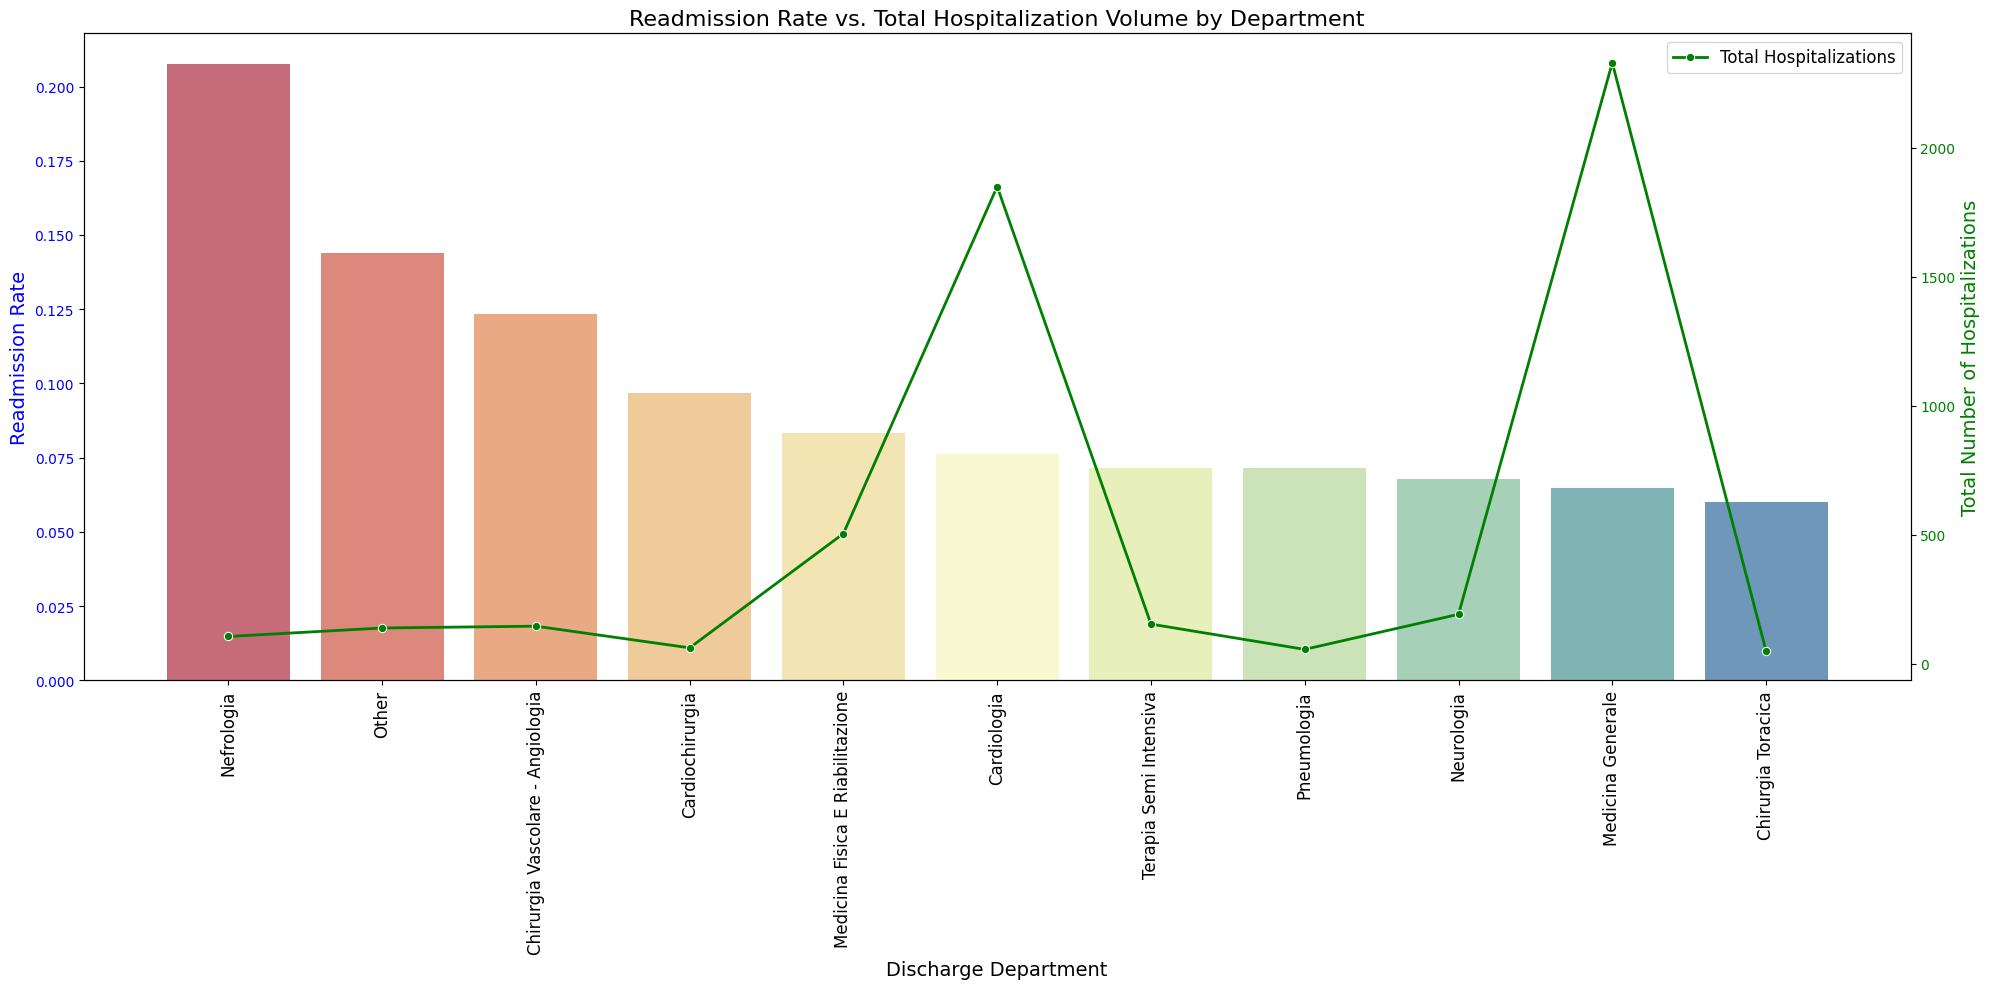

In [9]:
dept_stats = df.groupby('discharge_department_grouped')['is_readmitted'].agg(['mean', 'count'])
dept_stats = dept_stats.sort_values(by='mean', ascending=False)

# Create the figure and primary axis
fig, ax1 = plt.subplots(figsize=(20, 10))

# Plot Readmission Rate (Bar Chart) on Primary Y-Axis
sns.barplot(x=dept_stats.index, y=dept_stats['mean'], ax=ax1, palette='Spectral', alpha=0.8)
ax1.set_ylabel('Readmission Rate', fontsize=14, color='blue')
ax1.set_xlabel('Discharge Department', fontsize=14)
ax1.set_xticklabels(dept_stats.index, rotation=90, fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# Create secondary axis
ax2 = ax1.twinx()

# Plot Number of Hospitalizations (Line Chart) on Secondary Y-Axis
sns.lineplot(x=dept_stats.index, y=dept_stats['count'], ax=ax2, color='green', marker='o', linewidth=2, sort=False, label='Total Hospitalizations')
ax2.set_ylabel('Total Number of Hospitalizations', fontsize=14, color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Add a legend for the line
lines, labels = ax2.get_legend_handles_labels()
ax2.legend(lines, labels, loc='upper right', fontsize=12)

plt.title('Readmission Rate vs. Total Hospitalization Volume by Department', fontsize=16)
plt.tight_layout()
df.drop(columns=['discharge_department'], inplace=True)
df.drop(columns=['discharge_department_grouped'], inplace=True)

In [10]:
patients = pd.read_csv("../data/processed/modeling/patients_readmission_flag.csv")
train_pat, test_pat = train_test_split(
    patients,
    test_size=0.2, #80/20 split
    random_state=42, 
    stratify=patients["readmission_flag"] # Stratify based on readmission flag
)

train_ids = set(train_pat["crypted_patient_id"]) # Set of patient IDs in training set
test_ids  = set(test_pat["crypted_patient_id"]) # Set of patient IDs in test set

X_train = df[df["crypted_patient_id"].isin(train_ids)].copy().drop(columns=['crypted_patient_id']) # Training episodes
X_test  = df[df["crypted_patient_id"].isin(test_ids)].copy().drop(columns=['crypted_patient_id']) # Test episodes

y_train = X_train.pop("is_readmitted") # Training labels
y_test  = X_test.pop("is_readmitted") # Test labels

X_train.to_csv("../data/splits/train.csv", index=False)
X_test.to_csv("../data/splits/test.csv", index=False)
df.drop(columns=['crypted_patient_id'], inplace=True) # Drop patient ID from features

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# feature selection (variance threshold)
selector_var = VarianceThreshold(threshold=0) # 0 means remove strictly constant
selector_var.fit(X_train)
features_var = X_train.columns[selector_var.get_support()].tolist()
print(f"Variance Threshold kept {len(features_var)}/{len(X_train.columns)} features")

Variance Threshold kept 49/49 features


Text(0.5, 1.0, 'Correlation Matrix')

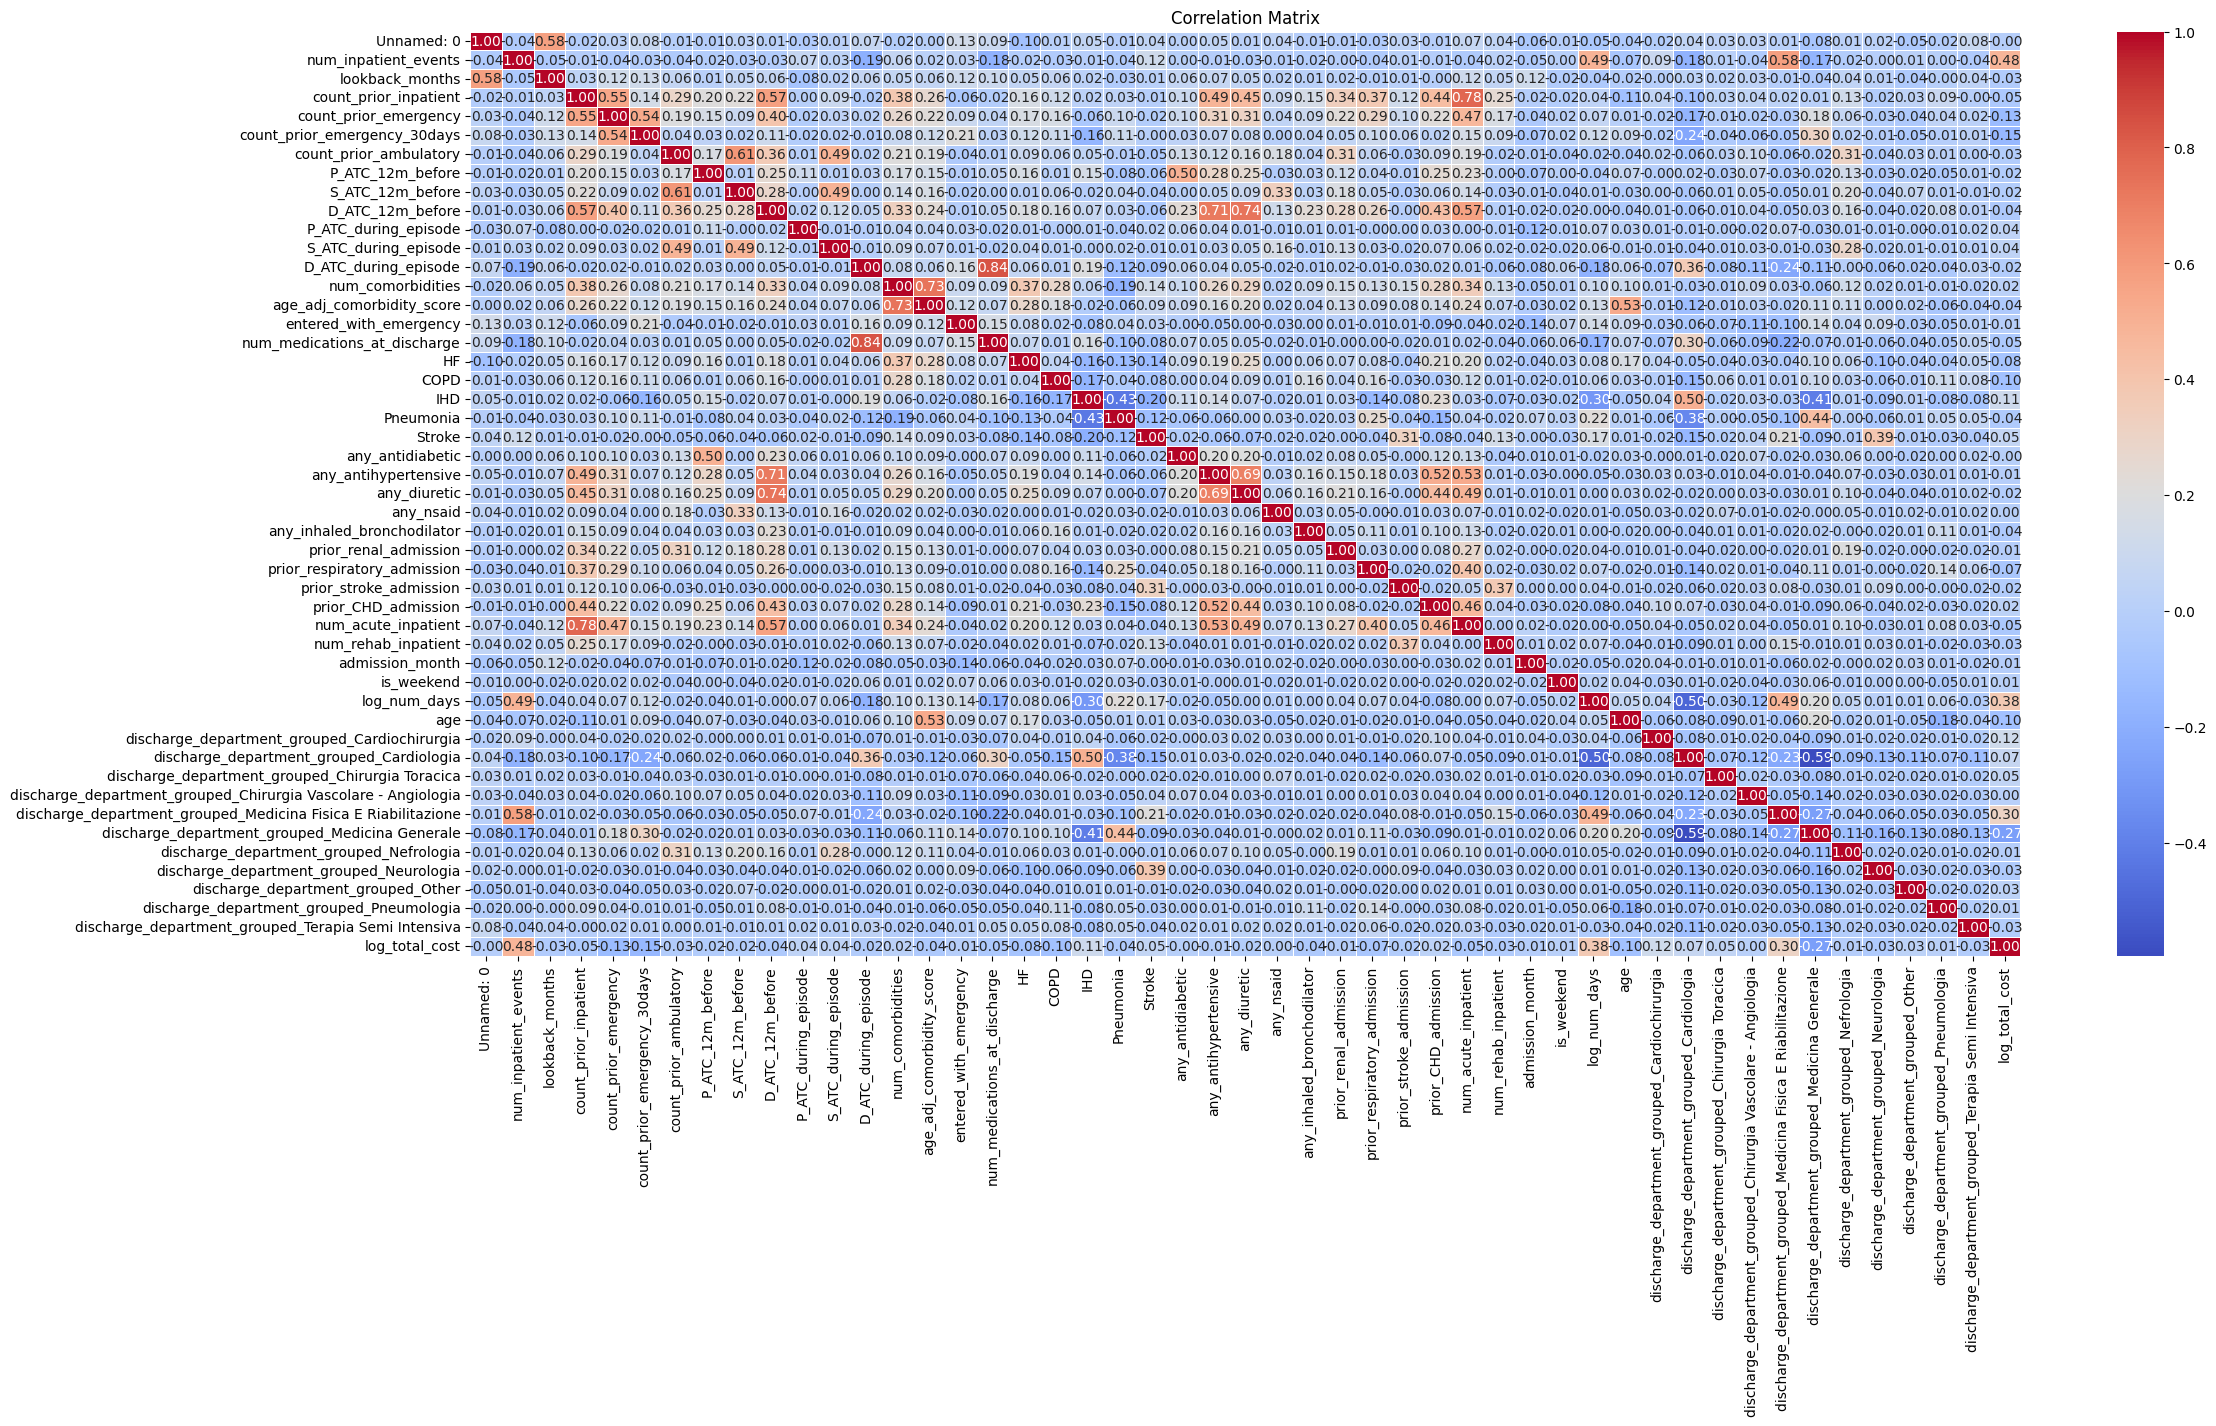

In [13]:
# remove highly correlated features (multicollinearity) doesnt need to be done on the scaled data, we can do it on the original data (because correlation is scale-invariant)
plt.figure(figsize=(25, 12))
corr_matrix = X_train[features_var].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt ='.2f')
plt.title('Correlation Matrix')
# plt.savefig('correlation_matrix.png')

In [14]:
# rfe on unscaled data with random forest, because tree-based models are not affected by feature scaling
rf = RandomForestClassifier(n_estimators=50,n_jobs=-1, random_state=42, class_weight='balanced')
#recursive feature elimination
rfe = RFE(estimator=rf, n_features_to_select=20) # Select top 20 features
rfe.fit(X_train[features_var], y_train)
rfe_features = np.array (features_var)[rfe.get_support()].tolist()
rfe_ranks = rfe.ranking_
print(f"RFE selected top 20 features: {rfe_features}")

RFE selected top 20 features: ['Unnamed: 0', 'lookback_months', 'count_prior_inpatient', 'count_prior_emergency', 'count_prior_emergency_30days', 'count_prior_ambulatory', 'P_ATC_12m_before', 'D_ATC_12m_before', 'D_ATC_during_episode', 'num_comorbidities', 'age_adj_comorbidity_score', 'entered_with_emergency', 'num_medications_at_discharge', 'IHD', 'num_acute_inpatient', 'admission_month', 'log_num_days', 'age', 'discharge_department_grouped_Medicina Generale', 'log_total_cost']


In [15]:
# lasso regression for feature selection, on scaled data because regularization is affected by feature scaling
l1 = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=42)
l1.fit(X_train_scaled, y_train)
lasso_features = np.array(features_var)[np.where(l1.coef_[0] != 0)[0]].tolist()
lasso_coefs =np.abs(l1.coef_)[0]
print(f"Lasso selected features: {lasso_features}")

Lasso selected features: ['Unnamed: 0', 'num_inpatient_events', 'lookback_months', 'count_prior_inpatient', 'count_prior_emergency', 'count_prior_emergency_30days', 'count_prior_ambulatory', 'P_ATC_12m_before', 'S_ATC_12m_before', 'D_ATC_12m_before', 'P_ATC_during_episode', 'S_ATC_during_episode', 'D_ATC_during_episode', 'num_comorbidities', 'age_adj_comorbidity_score', 'entered_with_emergency', 'num_medications_at_discharge', 'HF', 'COPD', 'IHD', 'Pneumonia', 'Stroke', 'any_antidiabetic', 'any_antihypertensive', 'any_diuretic', 'any_nsaid', 'any_inhaled_bronchodilator', 'prior_renal_admission', 'prior_respiratory_admission', 'prior_stroke_admission', 'prior_CHD_admission', 'num_acute_inpatient', 'num_rehab_inpatient', 'admission_month', 'is_weekend', 'log_num_days', 'age', 'discharge_department_grouped_Cardiochirurgia', 'discharge_department_grouped_Cardiologia', 'discharge_department_grouped_Chirurgia Toracica', 'discharge_department_grouped_Chirurgia Vascolare - Angiologia', 'discha

c:\Users\kevin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\kevin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [16]:
# mutual information, on unscaled data because tree-based models are not affected by feature scaling
mi_scores = mutual_info_classif(X_train[features_var], y_train, random_state=42)
mi_features = pd.Series(mi_scores, index=features_var).sort_values(ascending=False).head(20).index.tolist()
print(f"Mutual Information selected top 20 features: {mi_features}")

Mutual Information selected top 20 features: ['any_antihypertensive', 'log_total_cost', 'prior_CHD_admission', 'discharge_department_grouped_Pneumologia', 'Unnamed: 0', 'prior_respiratory_admission', 'D_ATC_12m_before', 'num_acute_inpatient', 'num_comorbidities', 'Stroke', 'P_ATC_12m_before', 'age', 'any_antidiabetic', 'count_prior_emergency', 'HF', 'age_adj_comorbidity_score', 'count_prior_inpatient', 'num_medications_at_discharge', 'any_nsaid', 'discharge_department_grouped_Cardiochirurgia']


In [17]:
# soft voting for feature selection - keep features that are selected by at least 2 methods
# combine feature lists
importance = pd.DataFrame({
    'Feature': features_var,
    'RFE_Rank': rfe_ranks,
    'Lasso_Coeff': lasso_coefs,
    'Mutual_Info': mi_scores
})

rfe_set = set(rfe_features)
lasso_set = set(lasso_features)
mi_set = set(mi_features)

all_features = rfe_set | lasso_set | mi_set
final_features = []

for feature in all_features:
    votes = 0
    if feature in rfe_set: votes += 1
    if feature in lasso_set: votes += 1
    if feature in mi_set: votes += 1
    
    # Keep if it has at least 2 votes
    if votes >= 2:
        final_features.append(feature)
        
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train[final_features], y_train)
result = permutation_importance(rf, X_test[final_features], y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring='roc_auc')
perm_imp_df = pd.DataFrame({
    'Feature': final_features,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
})
importance[importance['Feature'].isin(final_features)].to_csv("../data/processed/feature_selection/feature_importance_summary.csv", index=False) #get final features importance summary (univariate sorting)
perm_imp_df.sort_values(by='Importance_Mean', ascending=False).to_csv("../data/processed/feature_selection/permutation_importance.csv", index=False) # most important feature over final_features (multivariate)
print(f"Selected {len(final_features)} features.")
print("Final selected features:", final_features)


Selected 29 features.
Final selected features: ['Stroke', 'num_acute_inpatient', 'entered_with_emergency', 'any_antihypertensive', 'count_prior_emergency_30days', 'IHD', 'discharge_department_grouped_Medicina Generale', 'prior_CHD_admission', 'discharge_department_grouped_Pneumologia', 'any_antidiabetic', 'log_num_days', 'num_comorbidities', 'D_ATC_12m_before', 'age_adj_comorbidity_score', 'P_ATC_12m_before', 'count_prior_emergency', 'discharge_department_grouped_Cardiochirurgia', 'lookback_months', 'log_total_cost', 'count_prior_inpatient', 'D_ATC_during_episode', 'admission_month', 'prior_respiratory_admission', 'num_medications_at_discharge', 'any_nsaid', 'HF', 'age', 'Unnamed: 0', 'count_prior_ambulatory']


In [18]:
df.to_csv('../data/processed/inpatient_episode_fe.csv', index=False)